In [33]:
import torch
import torch.nn as nn
from torch.optim import SGD
from torch.utils.data import Dataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

import idx2numpy

In [13]:
MNIST_DIR = "../mnist/"

X_mnist = idx2numpy.convert_from_file(MNIST_DIR + "train-images-idx3-ubyte")
print("Önce:", X_mnist.shape, X_mnist.min(), X_mnist.max())

X_mnist = X_mnist.reshape(60000, -1) / 255.0
print("Sonra:", X_mnist.shape, X_mnist.min(), X_mnist.max())

y_mnist = idx2numpy.convert_from_file(MNIST_DIR + "train-labels-idx1-ubyte")

X_train, X_kalan, y_train, y_kalan = train_test_split(
    X_mnist, y_mnist, test_size=0.3, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(
    X_kalan, y_kalan, test_size=0.5, random_state=42)

print("\nTrain:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Önce: (60000, 28, 28) 0 255
Sonra: (60000, 784) 0.0 1.0

Train: (42000, 784) (42000,)
Val: (9000, 784) (9000,)
Test: (9000, 784) (9000,)


In [14]:
class MNistClassifier_1(nn.Module):
    def __init__(self):
        super().__init__()
        self.input_layer = nn.Linear(784, 10)

    def forward(self, x):
        x = self.input_layer(x)
        return x

In [15]:
class MNistClassifier_2(nn.Module):
    def __init__(self):
        super().__init__()
        self.input_layer = nn.Linear(784, 16)
        self.activation = nn.Sigmoid()
        self.output_layer = nn.Linear(16, 10)

    def forward(self, x):
        x = self.input_layer(x)
        x = self.activation(x)
        x = self.output_layer(x)
        return x

In [16]:
class MNistClassifier_3(nn.Module):
    def __init__(self):
        super().__init__()
        self.input_layer = nn.Linear(784, 16)
        self.activation = nn.ReLU()
        self.output_layer = nn.Linear(16, 10)

    def forward(self, x):
        x = self.input_layer(x)
        x = self.activation(x)
        x = self.output_layer(x)
        return x

In [17]:
class MnistDataset(Dataset):
    def __init__(self, X, y):
        self.x = torch.from_numpy(X.astype(np.float32))
        self.y = torch.from_numpy(y.astype(np.int64))

    def __getitem__(self, index):
        return self.x[index], self.y[index]

    def __len__(self):
        return self.x.shape[0]

In [34]:
def train_model(
        model,
        train_data_loader,
        validation_data_loader,
        test_data_loader,
        patience=3,
        model_name="my_model"
):
    criterion = nn.CrossEntropyLoss()
    optimizer = SGD(model.parameters(), lr=0.1)

    train_loss = []
    validation_loss = []

    best_val_loss = float("inf")
    patience_counter = 0

    for epoch in range(10000):
        # Training
        model.train()
        batch_train_loss = []

        for X, y in train_data_loader:
            optimizer.zero_grad()

            y_hat = model(X)
            loss = criterion(y_hat, y)

            loss.backward()
            optimizer.step()

            batch_train_loss.append(loss.item())

        epoch_train_loss = np.mean(batch_train_loss)
        train_loss.append(epoch_train_loss)

        # Validation
        model.eval()
        batch_validation_loss = []

        with torch.no_grad():
            for X, y in validation_data_loader:  # FIXED
                y_hat = model(X)
                loss = criterion(y_hat, y)
                batch_validation_loss.append(loss.item())

        epoch_val_loss = np.mean(batch_validation_loss)
        validation_loss.append(epoch_val_loss)

        print(
            f"Epoch {epoch+1}: Train Loss = {epoch_train_loss:.4f}, Val Loss = {epoch_val_loss:.4f}")

        # Early Stopping
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            patience_counter = 0
            best_model_state = model.state_dict()  # save best model
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

    # Restore best model
    model.load_state_dict(best_model_state)

    # Testing
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for X, y in test_data_loader:
            y_hat = model(X)
            predictions = torch.argmax(y_hat, dim=1)

            correct += (predictions == y).sum().item()
            total += y.size(0)

    test_accuracy = correct / total
    print(f"Test Accuracy: {test_accuracy:.4f}")

    torch.save(model.state_dict(), f"trained_models/{model_name}.pth")
    print(f"Model saved to: trained_models/{model_name}.pth")

    return train_loss, validation_loss, test_accuracy

In [29]:
# train
dataset_train = MnistDataset(X_train, y_train)
data_loader_train = DataLoader(
    dataset=dataset_train, batch_size=256, shuffle=True)

# validation
dataset_val = MnistDataset(X_val, y_val)
data_loader_val = DataLoader(
    dataset=dataset_val, batch_size=256, shuffle=False)

# test
dataset_test = MnistDataset(X_test, y_test)
data_loader_test = DataLoader(
    dataset=dataset_test, batch_size=256, shuffle=False)

In [30]:
def plot_loss(train_loss, validation_loss):
    plt.figure(figsize=(8, 4))
    plt.plot(train_loss, c="b", label="Train")
    plt.plot(validation_loss, c="r", label="Validation")
    plt.legend()
    plt.show()

Epoch 1: Train Loss = 0.8070, Val Loss = 0.5232
Epoch 2: Train Loss = 0.4707, Val Loss = 0.4329
Epoch 3: Train Loss = 0.4139, Val Loss = 0.3937
Epoch 4: Train Loss = 0.3875, Val Loss = 0.3706
Epoch 5: Train Loss = 0.3686, Val Loss = 0.3587
Epoch 6: Train Loss = 0.3549, Val Loss = 0.3465
Epoch 7: Train Loss = 0.3453, Val Loss = 0.3382
Epoch 8: Train Loss = 0.3373, Val Loss = 0.3323
Epoch 9: Train Loss = 0.3310, Val Loss = 0.3264
Epoch 10: Train Loss = 0.3251, Val Loss = 0.3229
Epoch 11: Train Loss = 0.3235, Val Loss = 0.3214
Epoch 12: Train Loss = 0.3182, Val Loss = 0.3189
Epoch 13: Train Loss = 0.3142, Val Loss = 0.3145
Epoch 14: Train Loss = 0.3115, Val Loss = 0.3128
Epoch 15: Train Loss = 0.3084, Val Loss = 0.3103
Epoch 16: Train Loss = 0.3063, Val Loss = 0.3074
Epoch 17: Train Loss = 0.3027, Val Loss = 0.3050
Epoch 18: Train Loss = 0.3017, Val Loss = 0.3038
Epoch 19: Train Loss = 0.2997, Val Loss = 0.3042
Epoch 20: Train Loss = 0.2968, Val Loss = 0.3009
Epoch 21: Train Loss = 0.2966

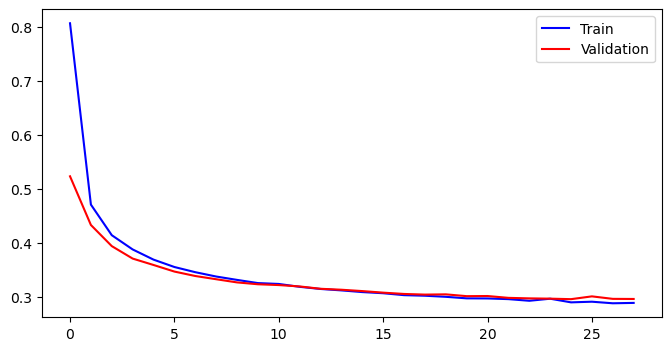

In [35]:
model_1 = MNistClassifier_1()
train_loss, validation_loss, test_accuracy = \
    train_model(
        model_1, data_loader_train, data_loader_val, data_loader_test, patience=3, model_name="model_1"
    )

plot_loss(train_loss, validation_loss)

Epoch 1: Train Loss = 2.0460, Val Loss = 1.7010
Epoch 2: Train Loss = 1.3870, Val Loss = 1.1302
Epoch 3: Train Loss = 0.9780, Val Loss = 0.8508
Epoch 4: Train Loss = 0.7682, Val Loss = 0.6940
Epoch 5: Train Loss = 0.6445, Val Loss = 0.5962
Epoch 6: Train Loss = 0.5654, Val Loss = 0.5296
Epoch 7: Train Loss = 0.5074, Val Loss = 0.4817
Epoch 8: Train Loss = 0.4658, Val Loss = 0.4453
Epoch 9: Train Loss = 0.4341, Val Loss = 0.4183
Epoch 10: Train Loss = 0.4113, Val Loss = 0.3971
Epoch 11: Train Loss = 0.3920, Val Loss = 0.3800
Epoch 12: Train Loss = 0.3761, Val Loss = 0.3653
Epoch 13: Train Loss = 0.3615, Val Loss = 0.3539
Epoch 14: Train Loss = 0.3513, Val Loss = 0.3444
Epoch 15: Train Loss = 0.3433, Val Loss = 0.3350
Epoch 16: Train Loss = 0.3305, Val Loss = 0.3254
Epoch 17: Train Loss = 0.3228, Val Loss = 0.3192
Epoch 18: Train Loss = 0.3151, Val Loss = 0.3123
Epoch 19: Train Loss = 0.3111, Val Loss = 0.3065
Epoch 20: Train Loss = 0.3032, Val Loss = 0.3022
Epoch 21: Train Loss = 0.2972

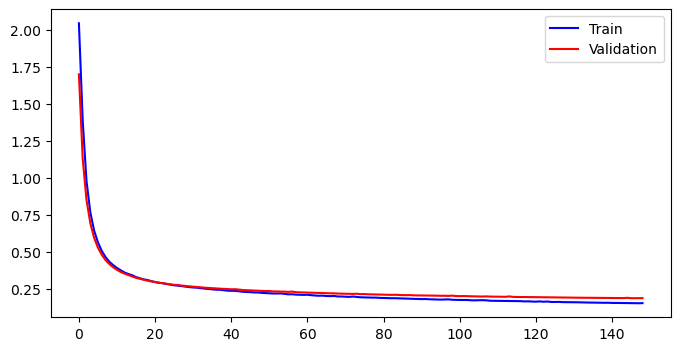

In [36]:
model_2 = MNistClassifier_2()
train_loss, validation_loss, test_accuracy = \
    train_model(
        model_2, data_loader_train, data_loader_val, data_loader_test, patience=3, model_name="model_2"
    )

plot_loss(train_loss, validation_loss)

Epoch 1: Train Loss = 1.1040, Val Loss = 0.6212
Epoch 2: Train Loss = 0.4335, Val Loss = 0.4054
Epoch 3: Train Loss = 0.3607, Val Loss = 0.3419
Epoch 4: Train Loss = 0.3317, Val Loss = 0.4693
Epoch 5: Train Loss = 0.3136, Val Loss = 0.3536
Epoch 6: Train Loss = 0.2993, Val Loss = 0.3124
Epoch 7: Train Loss = 0.2889, Val Loss = 0.3268
Epoch 8: Train Loss = 0.2782, Val Loss = 0.2843
Epoch 9: Train Loss = 0.2687, Val Loss = 0.2715
Epoch 10: Train Loss = 0.2611, Val Loss = 0.2943
Epoch 11: Train Loss = 0.2528, Val Loss = 0.2740
Epoch 12: Train Loss = 0.2463, Val Loss = 0.2618
Epoch 13: Train Loss = 0.2386, Val Loss = 0.2503
Epoch 14: Train Loss = 0.2324, Val Loss = 0.2589
Epoch 15: Train Loss = 0.2271, Val Loss = 0.2436
Epoch 16: Train Loss = 0.2271, Val Loss = 0.2978
Epoch 17: Train Loss = 0.2187, Val Loss = 0.3289
Epoch 18: Train Loss = 0.2128, Val Loss = 0.2460
Early stopping triggered.
Test Accuracy: 0.9313
Model saved to: trained_models/model_3.pth


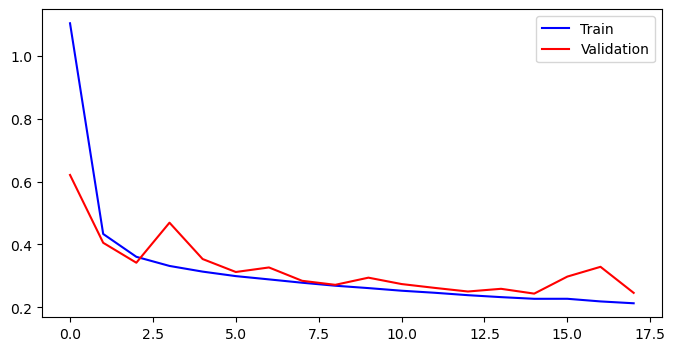

In [41]:
model_3 = MNistClassifier_3()
train_loss, validation_loss, test_accuracy = \
    train_model(
        model_3, data_loader_train, data_loader_val, data_loader_test, patience=3, model_name="model_3"
    )

plot_loss(train_loss, validation_loss)

In [43]:
# Load trained model
model = MNistClassifier_2()
model.load_state_dict(torch.load("trained_models/model_2.pth"))
model.eval()

MNistClassifier_2(
  (input_layer): Linear(in_features=784, out_features=16, bias=True)
  (activation): Sigmoid()
  (output_layer): Linear(in_features=16, out_features=10, bias=True)
)

In [50]:
""" 
class MNistClassifier_2(nn.Module):
    def __init__(self):
        super().__init__()
        self.input_layer = nn.Linear(784, 16)
        self.activation = nn.Sigmoid()
        self.output_layer = nn.Linear(16, 10)

    def forward(self, x):
        x = self.input_layer(x)
        x = self.activation(x)
        x = self.output_layer(x)
        return x

"""
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable_params}", (16 * (784 + 1)) + (10 * (16 + 1)))

Trainable parameters: 12730 12730


In [52]:
with torch.no_grad():
    for X, y in data_loader_test:
        outputs = model(X)
        break

print(outputs.size())

torch.Size([256, 10])


In [53]:
outputs[:3]

tensor([[-5.7712,  0.0477,  2.1440,  0.2299, -1.9707, -1.8417, -4.5478,  7.3446,
         -0.3620,  2.6419],
        [ 8.5131, -2.6471, -1.4248, -3.8331, -5.6297,  2.7195,  0.8044, -0.4158,
          0.6084,  0.2955],
        [-0.0412, -3.1466, -6.1607,  0.7641,  1.1203,  9.2860, -3.5874, -2.6506,
          1.5837,  2.6210]])

In [57]:
preds = torch.argmax(outputs, dim=1)
print(preds[:3], y_test[:3])

tensor([7, 0, 5]) [7 0 5]
